In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [ ]:
df = pd.read_csv('netflix_titles.csv')

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.nunique()

,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1767
release_year,74
rating,17
duration,220


check misssing values

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
(df.isnull().sum() / len(df)) * 100


,0
show_id,0.000000
type,0.000000
title,0.000000
director,29.908028
cast,9.367549
country,9.435676
date_added,0.113546
release_year,0.000000
rating,0.045418
duration,0.034064


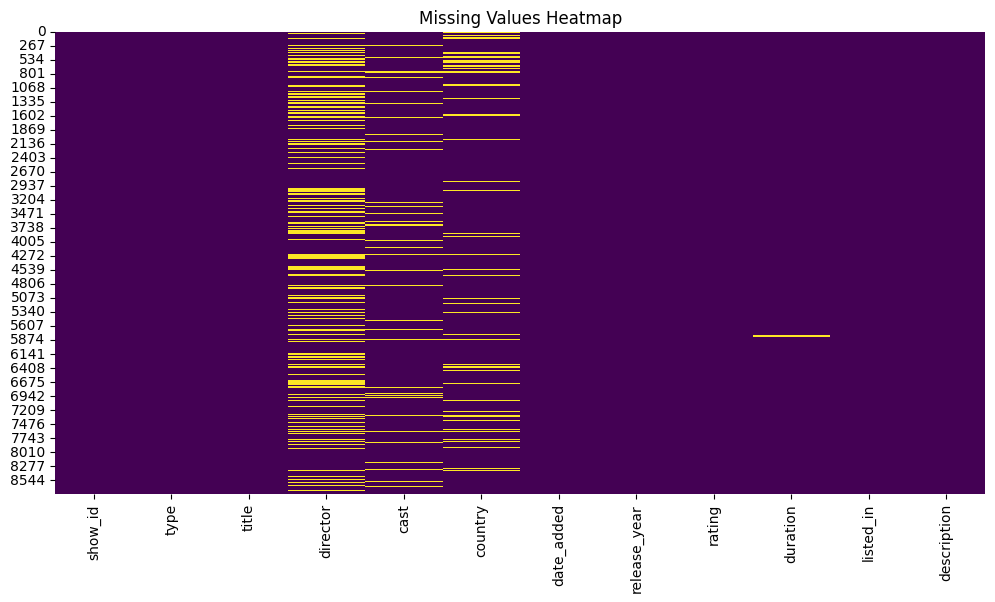

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
df.replace(["", "Unknown", "none", "None", " "], np.nan, inplace=True)

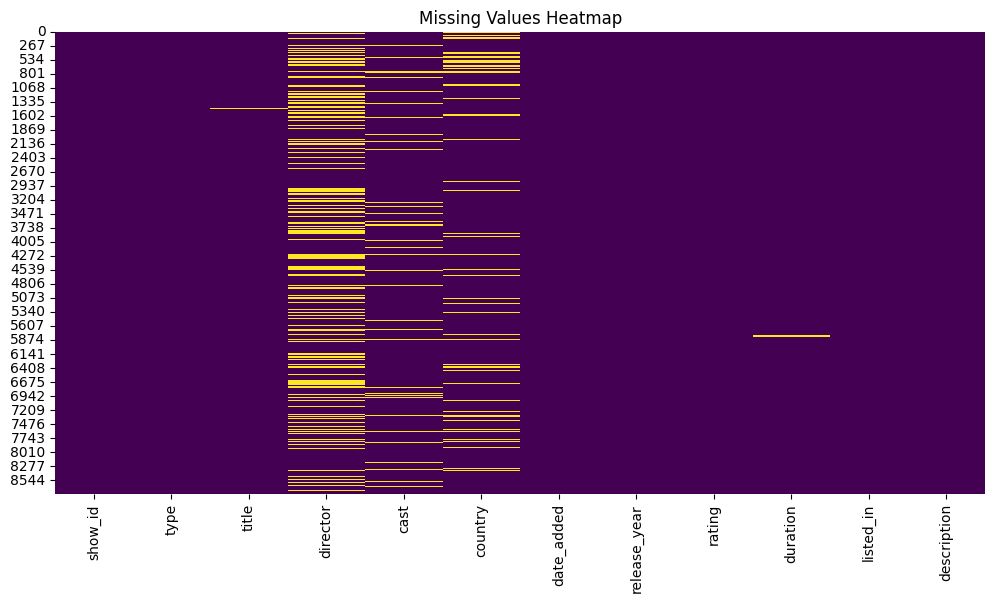

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# Checking the distribution of values in the column

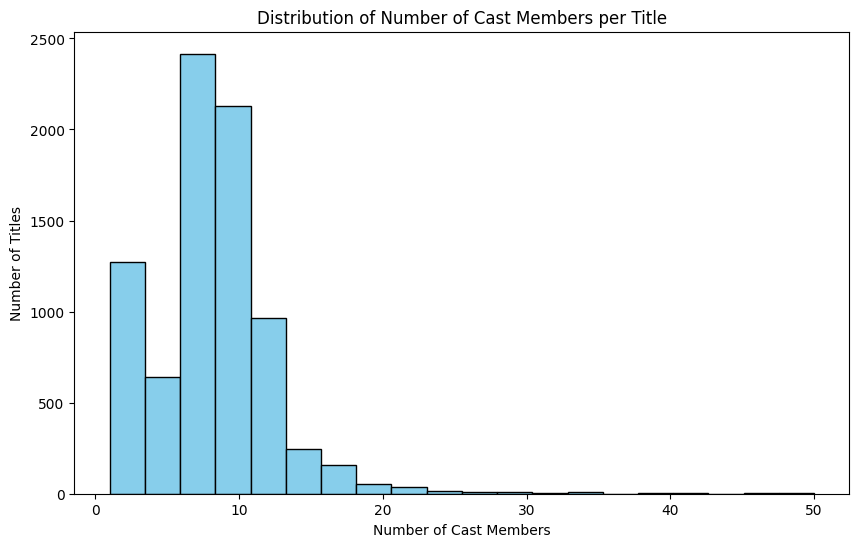

In [ ]:
df['num_cast'] = df['cast'].dropna().apply(lambda x: len(x.split(',')) if pd.notna(x) else 0)

plt.figure(figsize=(10, 6))
df['num_cast'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Number of Cast Members per Title')
plt.xlabel('Number of Cast Members')
plt.ylabel('Number of Titles')
plt.grid(False)
plt.show()

<Axes: title={'center': 'Top 10 Directors by Count'}, ylabel='director'>

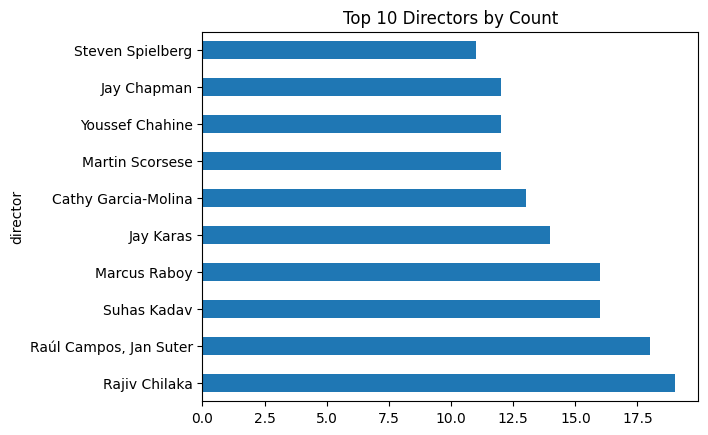

In [ ]:
df['director'].value_counts().head(10).plot(kind='barh', title='Top 10 Directors by Count')


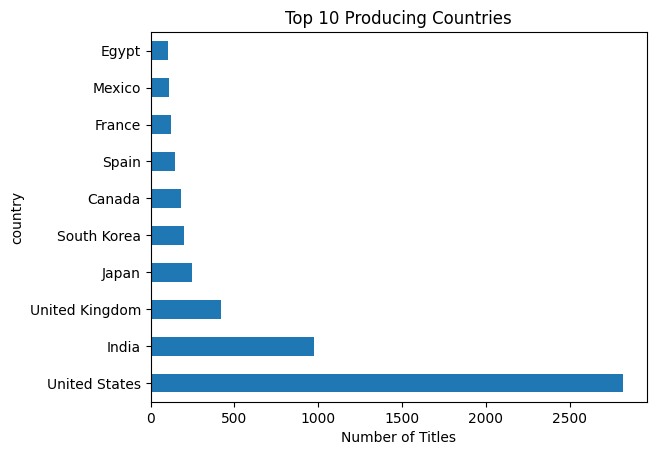

In [ ]:
df['country'].value_counts().head(10).plot(kind='barh', title='Top 10 Producing Countries')
plt.xlabel('Number of Titles')
plt.show()

In [ ]:
df.groupby('type')['country'].nunique().sort_values()

,country
type,
TV Show,196
Movie,651


In [ ]:
type_country_map = (
    df[df['country'].notna()]
    .groupby('type')['country']
    .agg(lambda x: x.mode()[0])
)
def fill_country(row):
    if pd.isna(row['country']):
        return type_country_map.get(row['type'], 'Unknown')
    else:
        return row['country']

df['country'] = df.apply(fill_country, axis=1)

In [ ]:
missing_percent = df['country'].isnull().mean() * 100

In [ ]:
print(missing_percent)

0.0


In [ ]:
country_director_map = (
    df[df['director'].notna()]
    .groupby('country')['director']
    .agg(lambda x: x.mode()[0])
)


def fill_director(row):
    if pd.isna(row['director']):
        return country_director_map.get(row['country'], 'Unknown')
    else:
        return row['director']
df['director'] = df.apply(fill_director, axis=1)

In [ ]:
print("Missing in director:", df['director'].isnull().sum())

Missing in director: 0


In [ ]:
df.dropna(subset=['cast', 'date_added', 'rating', 'duration','title'], inplace=True)

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


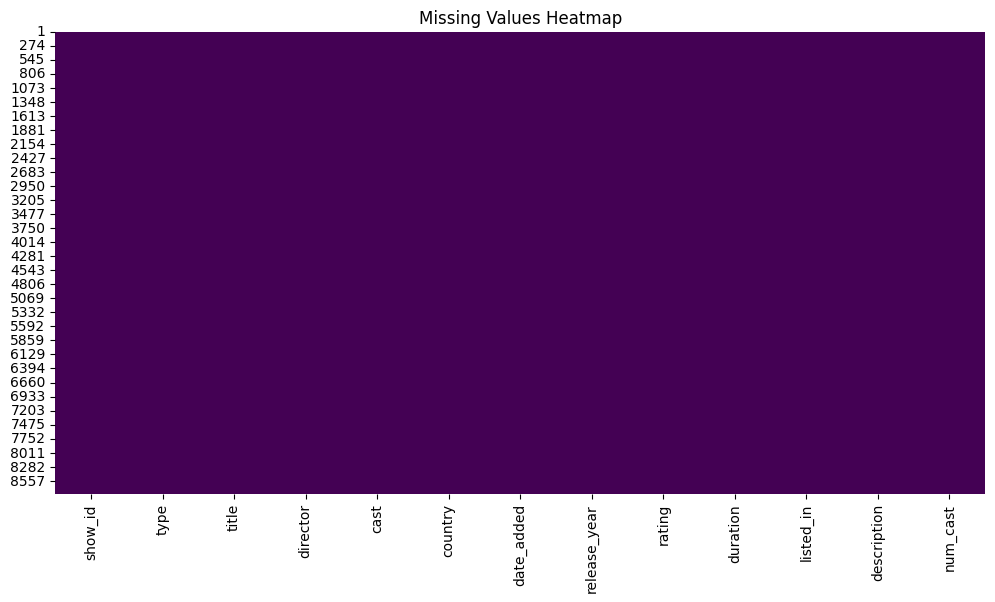

In [ ]:
### This heatmap helps identify missing values in the dataframe
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
total_titles = df.shape[0]
print("Total Titles:", total_titles)


Total Titles: 7964


In [ ]:
type_counts = df['type'].value_counts()
type_percentages = df['type'].value_counts(normalize=True) * 100


In [ ]:
type_counts

,count
type,
Movie,5650
TV Show,2314


In [ ]:
type_percentages

,proportion
type,
Movie,70.944249
TV Show,29.055751


In [ ]:
top_countries = df['country'].value_counts().head(10)
top_countries

,count
country,
United States,3154
India,940
United Kingdom,350
Japan,238
South Korea,196
Canada,162
Spain,127
France,106
Turkey,105


Exploratory Data Analysis

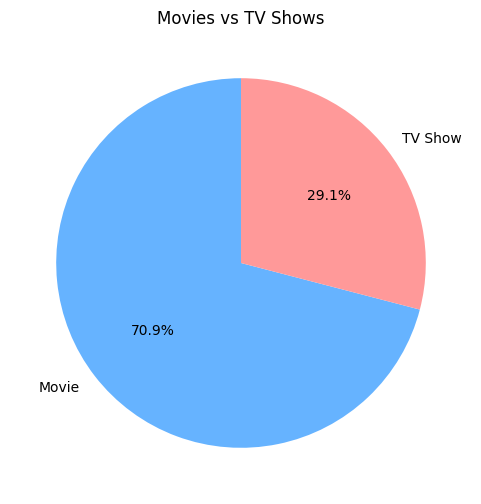

In [ ]:
##What is the most popular type? Movies or TV Shows?
type_counts = df['type'].value_counts()
plt.figure(figsize=(6,6))
type_counts.plot.pie(autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
plt.title('Movies vs TV Shows')
plt.ylabel('')
plt.show()


In [ ]:
##The countries that produce the most content?
movies_df = df[df['type'] == 'Movie']
top_movie_countries = movies_df['country'].value_counts().head(10)
print(top_movie_countries)

country
United States     2235
India              878
United Kingdom     173
Canada             109
Egypt               91
Spain               85
Nigeria             84
Turkey              76
Indonesia           76
Japan               74
Name: count, dtype: int64


/tmp/ipython-input-29-1991933944.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_movie_countries.values, y=top_movie_countries.index, palette='Set2')


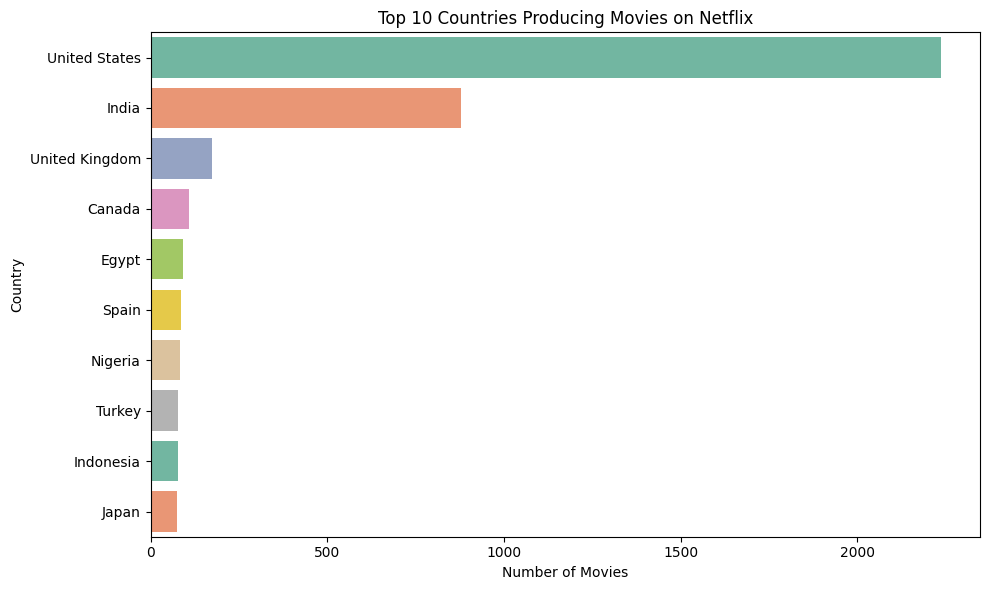

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_movie_countries.values, y=top_movie_countries.index, palette='Set2')
plt.title('Top 10 Countries Producing Movies on Netflix')
plt.xlabel('Number of Movies')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

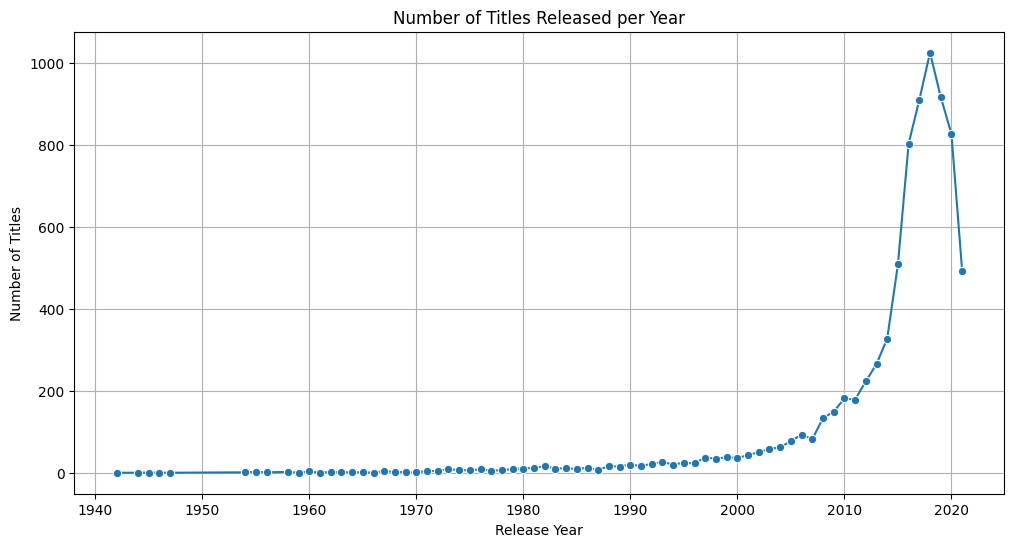

In [ ]:
##How has content production changed over the years?
titles_per_year = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
sns.lineplot(x=titles_per_year.index, y=titles_per_year.values, marker='o')
plt.title('Number of Titles Released per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

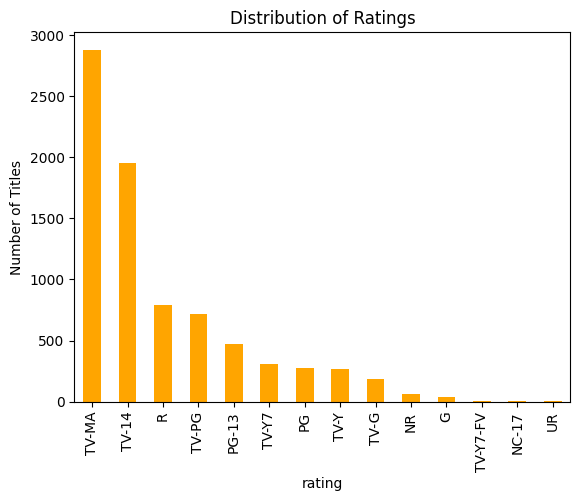

In [ ]:
##What is the most common age rating?
df['rating'].value_counts().plot(kind='bar', color='orange', title='Distribution of Ratings')
plt.ylabel('Number of Titles')
plt.show()


In [ ]:
from collections import Counter
all_genres = movies_df['listed_in'].dropna().str.split(', ')
flat_genres = [genre for sublist in all_genres for genre in sublist]
top_genres = Counter(flat_genres).most_common(10)

/tmp/ipython-input-33-770134035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_df, x='count', y='genre', palette='coolwarm')


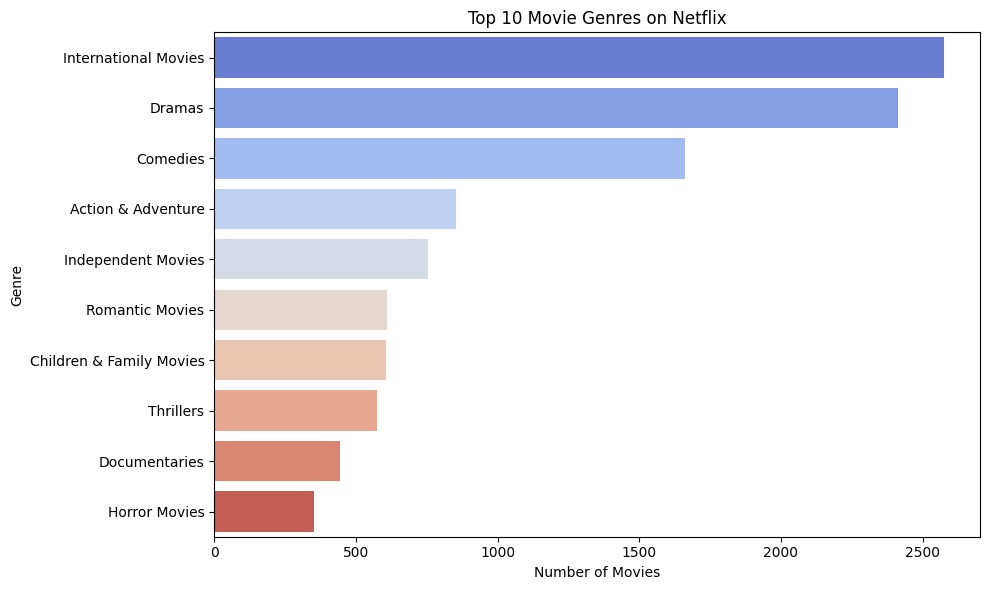

In [ ]:
genre_df = pd.DataFrame(top_genres, columns=['genre', 'count'])

plt.figure(figsize=(10,6))
sns.barplot(data=genre_df, x='count', y='genre', palette='coolwarm')
plt.title('Top 10 Movie Genres on Netflix')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

/tmp/ipython-input-34-1095825634.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=actors_df, x='Count', y='Actor', palette='Blues_d')


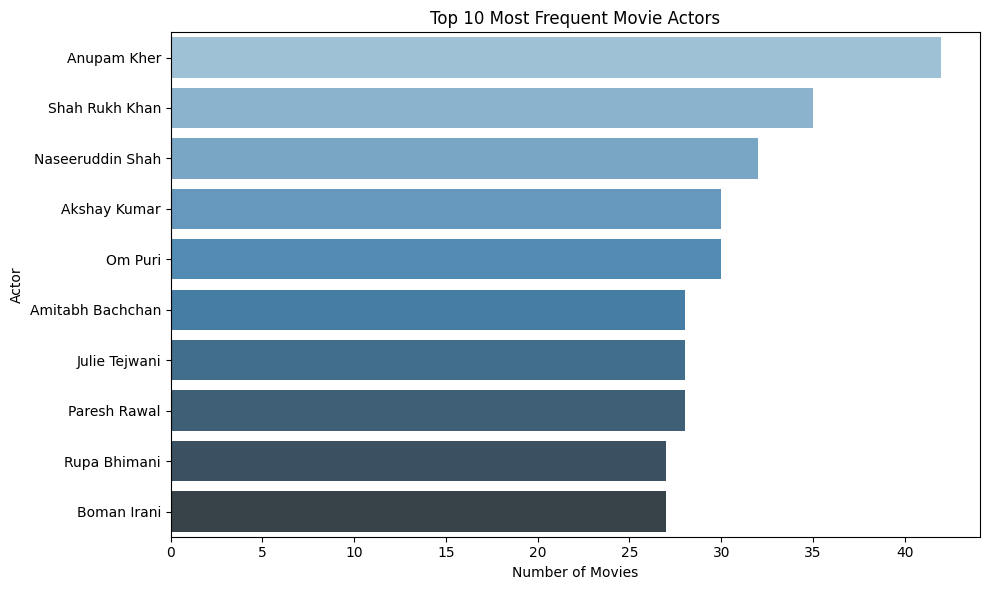

In [ ]:
all_cast = movies_df['cast'].dropna().str.split(', ')
flat_cast = [c.strip() for sublist in all_cast for c in sublist]
top_actors = Counter(flat_cast).most_common(10)
actors_df = pd.DataFrame(top_actors, columns=['Actor', 'Count'])

plt.figure(figsize=(10,6))
sns.barplot(data=actors_df, x='Count', y='Actor', palette='Blues_d')
plt.title('Top 10 Most Frequent Movie Actors')
plt.xlabel('Number of Movies')
plt.ylabel('Actor')
plt.tight_layout()
plt.show()


Netflix Data Analysis – Key Insights

In [ ]:
## 1. Movies vs TV Shows
##The content on Netflix heavily leans towards movies, which make up approximately 70% of all titles.
###This indicates that Netflix invests more in producing or acquiring movies than TV shows.



In [ ]:
## 2. Top Producing Countries
## Insight: The United States and India are the leading countries in content production on Netflix.
## This reflects the strength of their entertainment industries and Netflix’s strategic partnerships in these markets.

In [ ]:
## 3. Content Release Trends
##Insight: There has been a significant increase in the number of titles released after 2015.
#This highlights Netflix’s aggressive expansion in original content production in recent years

In [ ]:
## 4. Rating Distribution
## Insight: The most common content ratings are TV-MA and TV-14, indicating that the majority of titles target adult and teen audiences.
## There's relatively less focus on child-friendly or family-oriented content.



In [ ]:
## 5 . Most Common Genres
## Insight: Drama is the most dominant genre on the platform, followed by Comedy.
## This suggests that audiences prefer emotionally-driven and relatable stories, while comedy provides widespread appeal and entertainment value.

In [ ]:
## 6. Most Frequent Actors
## Insight: A few actors appear repeatedly across multiple titles on Netflix.
## This may imply Netflix’s tendency to reuse familiar faces to maintain audience engagement and loyalty